In [1]:
from src.KNN.KNNClassifier import KNNClassifier
from src.KNN.metrics import accuracy, f1_score
from src.KNN.Scalers import MinMaxScaler, RobustScaler, StandardScaler
from src.KNN.split_train_data import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

True


In [2]:
df = pd.read_csv('spam.csv')
df.describe()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_:,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,label
count,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,...,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000
mean,0.104553,0.213015,0.280656,0.065425,0.312223,0.095901,0.114208,0.105295,0.090067,0.239413,...,0.038575,0.139030,0.016976,0.269071,0.075811,0.044238,5.191515,52.172789,283.289285,0.394045
std,0.305358,1.290575,0.504143,1.395151,0.672513,0.273824,0.391441,0.401071,0.278616,0.644755,...,0.243471,0.270355,0.109394,0.815672,0.245882,0.429342,31.729449,194.891310,606.347851,0.488698
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.588000,6.000000,35.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.065000,0.000000,0.000000,0.000000,0.000000,2.276000,15.000000,95.000000,0.000000
75%,0.000000,0.000000,0.420000,0.000000,0.380000,0.000000,0.000000,0.000000,0.000000,0.160000,...,0.000000,0.188000,0.000000,0.315000,0.052000,0.000000,3.706000,43.000000,266.000000,1.000000
max,4.540000,14.280000,5.100000,42.810000,10.000000,5.880000,7.270000,11.110000,5.260000,18.180000,...,4.385000,9.752000,4.081000,32.478000,6.003000,19.829000,1102.500000,9989.000000,15841.000000,1.000000


In [3]:
df["label"]

0       1
1       1
2       1
3       1
4       1
       ..
4596    0
4597    0
4598    0
4599    0
4600    0
Name: label, Length: 4601, dtype: int64

In [9]:
y = list(df["label"])

def row_to_tuple_of_numbers(row):
  numbers = []
  for i, value in enumerate(row):
      if i == 57:
          continue
      numbers.append(value)
  return tuple(numbers)

X = df.apply(row_to_tuple_of_numbers, axis=1).tolist()
X[0]

(0.0,
 0.64,
 0.64,
 0.0,
 0.32,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.64,
 0.0,
 0.0,
 0.0,
 0.32,
 0.0,
 1.29,
 1.93,
 0.0,
 0.96,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.778,
 0.0,
 0.0,
 3.756,
 61.0,
 278.0)

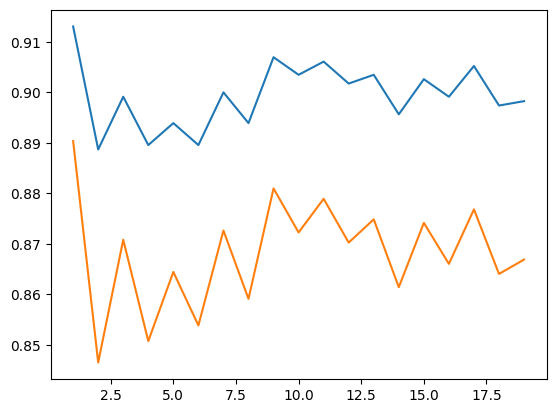

In [11]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, np.array(y), 0.25)
accuracy_scores = []
f1_scores = []

for k in range(1, 20):
    knn = KNNClassifier(k, 10)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    accuracy_scores.append(accuracy(y_pred, y_test))
    f1_scores.append(f1_score(y_pred, y_test))

plt.plot(range(1, 20), accuracy_scores)
plt.plot(range(1, 20), f1_scores)
plt.show()

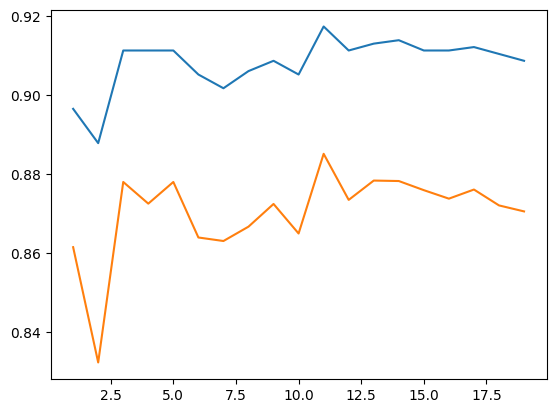

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[0]

X_train, X_test, y_train, y_test = train_test_split(X_scaled, np.array(y), 0.25)

accuracy_scores = []
f1_scores = []

for k in range(1, 20):
    knn = KNNClassifier(k, 10)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    accuracy_scores.append(accuracy(y_pred, y_test))
    f1_scores.append(f1_score(y_pred, y_test))

plt.plot(range(1, 20), accuracy_scores)
plt.plot(range(1, 20), f1_scores)
plt.show()

In [34]:
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[0]
X_scaled = np.nan_to_num(X_scaled, nan=0)
X_scaled[0]


array([ 0.00000000e+000,  1.79769313e+308,  1.52380952e+000,
        0.00000000e+000,  8.42105263e-001,  0.00000000e+000,
        0.00000000e+000,  0.00000000e+000,  0.00000000e+000,
        0.00000000e+000,  0.00000000e+000,  6.75000000e-001,
        0.00000000e+000,  0.00000000e+000,  0.00000000e+000,
        3.20000000e+000,  0.00000000e+000,  1.79769313e+308,
        2.34848485e-001,  0.00000000e+000,  5.82677165e-001,
        0.00000000e+000,  0.00000000e+000,  0.00000000e+000,
        0.00000000e+000,  0.00000000e+000,  0.00000000e+000,
        0.00000000e+000,  0.00000000e+000,  0.00000000e+000,
        0.00000000e+000,  0.00000000e+000,  0.00000000e+000,
        0.00000000e+000,  0.00000000e+000,  0.00000000e+000,
        0.00000000e+000,  0.00000000e+000,  0.00000000e+000,
        0.00000000e+000,  0.00000000e+000,  0.00000000e+000,
        0.00000000e+000,  0.00000000e+000,  0.00000000e+000,
        0.00000000e+000,  0.00000000e+000,  0.00000000e+000,
        0.00000000e+000,

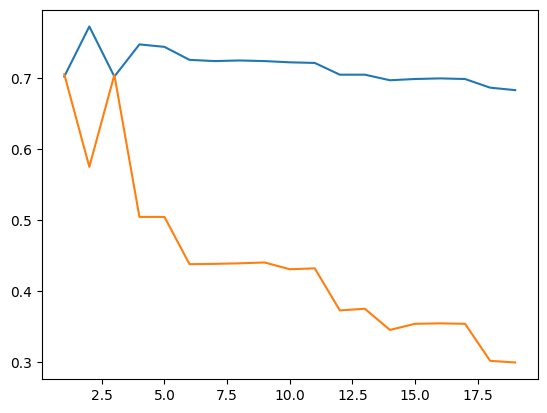

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, np.array(y), 0.25)
accuracy_scores = []
f1_scores = []

for k in range(1, 20):
    knn = KNNClassifier(k, 10)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    accuracy_scores.append(accuracy(y_pred, y_test))
    f1_scores.append(f1_score(y_pred, y_test))

plt.plot(range(1, 20), accuracy_scores)
plt.plot(range(1, 20), f1_scores)
plt.show()